# Global map of SST anomalies, absolute and standardised

In [7]:
#inputs/outputs
clst = '1982' ; clen = '2011'
stdat = '2025-07' ; endat = '2026-06'

diri = '/g/data/gv90/wrh581/OISST/'
fili = 'OIv2_SST_1982-2026.nc'
var_name = 'sst'

diro = '/g/data/jk72/wrh581/Obs-seaice-analysis/plots/'
filo = 'OISST_global_anom_map_'+stdat+'-'+endat+'.gif'


In [2]:
#set up: import packages 
import numpy as np
import xarray as xr
import cmocean as cm
import cartopy as ccrs
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from datetime import datetime


#kill the flox warning!
import logging
logging.getLogger("flox").setLevel(logging.WARNING)

### read data

In [8]:
sst = xr.open_dataset(diri+fili)
sst

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 538, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1981-09-01 1981-10-01 ... 2026-06-01
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, lat, lon) float32 2GB ...
Attributes:
    Conventions:    CF-1.5
    title:          NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea Surf...
    institution:    NOAA/National Centers for Environmental Information
    source:         NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface-temp...
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    version:        Version 2.1
    comment:        Reynolds, et al.(2007) Daily High-Resolution-Blended Anal...

### calc anoms

In [9]:
#climatology
cldata = sst.sel(time=slice(clst,clen)).groupby('time.month')
clim = cldata.mean('time')  
sd  = cldata.std('time')

#anoms
anom = sst.sel(time=slice(stdat,endat)).groupby('time.month') - clim
anom_norm = anom.groupby('time.month')/sd

anom = anom[var_name].compute()
anom_norm = anom_norm[var_name].compute()

### plot

In [10]:
colmap = cm.cm.balance ; 
clev  = np.arange(-5., 5., 0.5)

# plt.figure(figsize=(20,17), dpi=300)

# def plot(pdata, panel, tString, cbarString):



# plot(anom, 1, 'SST anomaly', 'SST ($^o$C)')
# plot(anom_norm, 2, 'Normalised SST anomaly','$sigma$')


# plt.suptitle(stdat+' - '+endat, fontsize=30)
# plt.savefig(diro+filo, bbox_inches='tight')

### animation for each month

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.PillowWriter'>


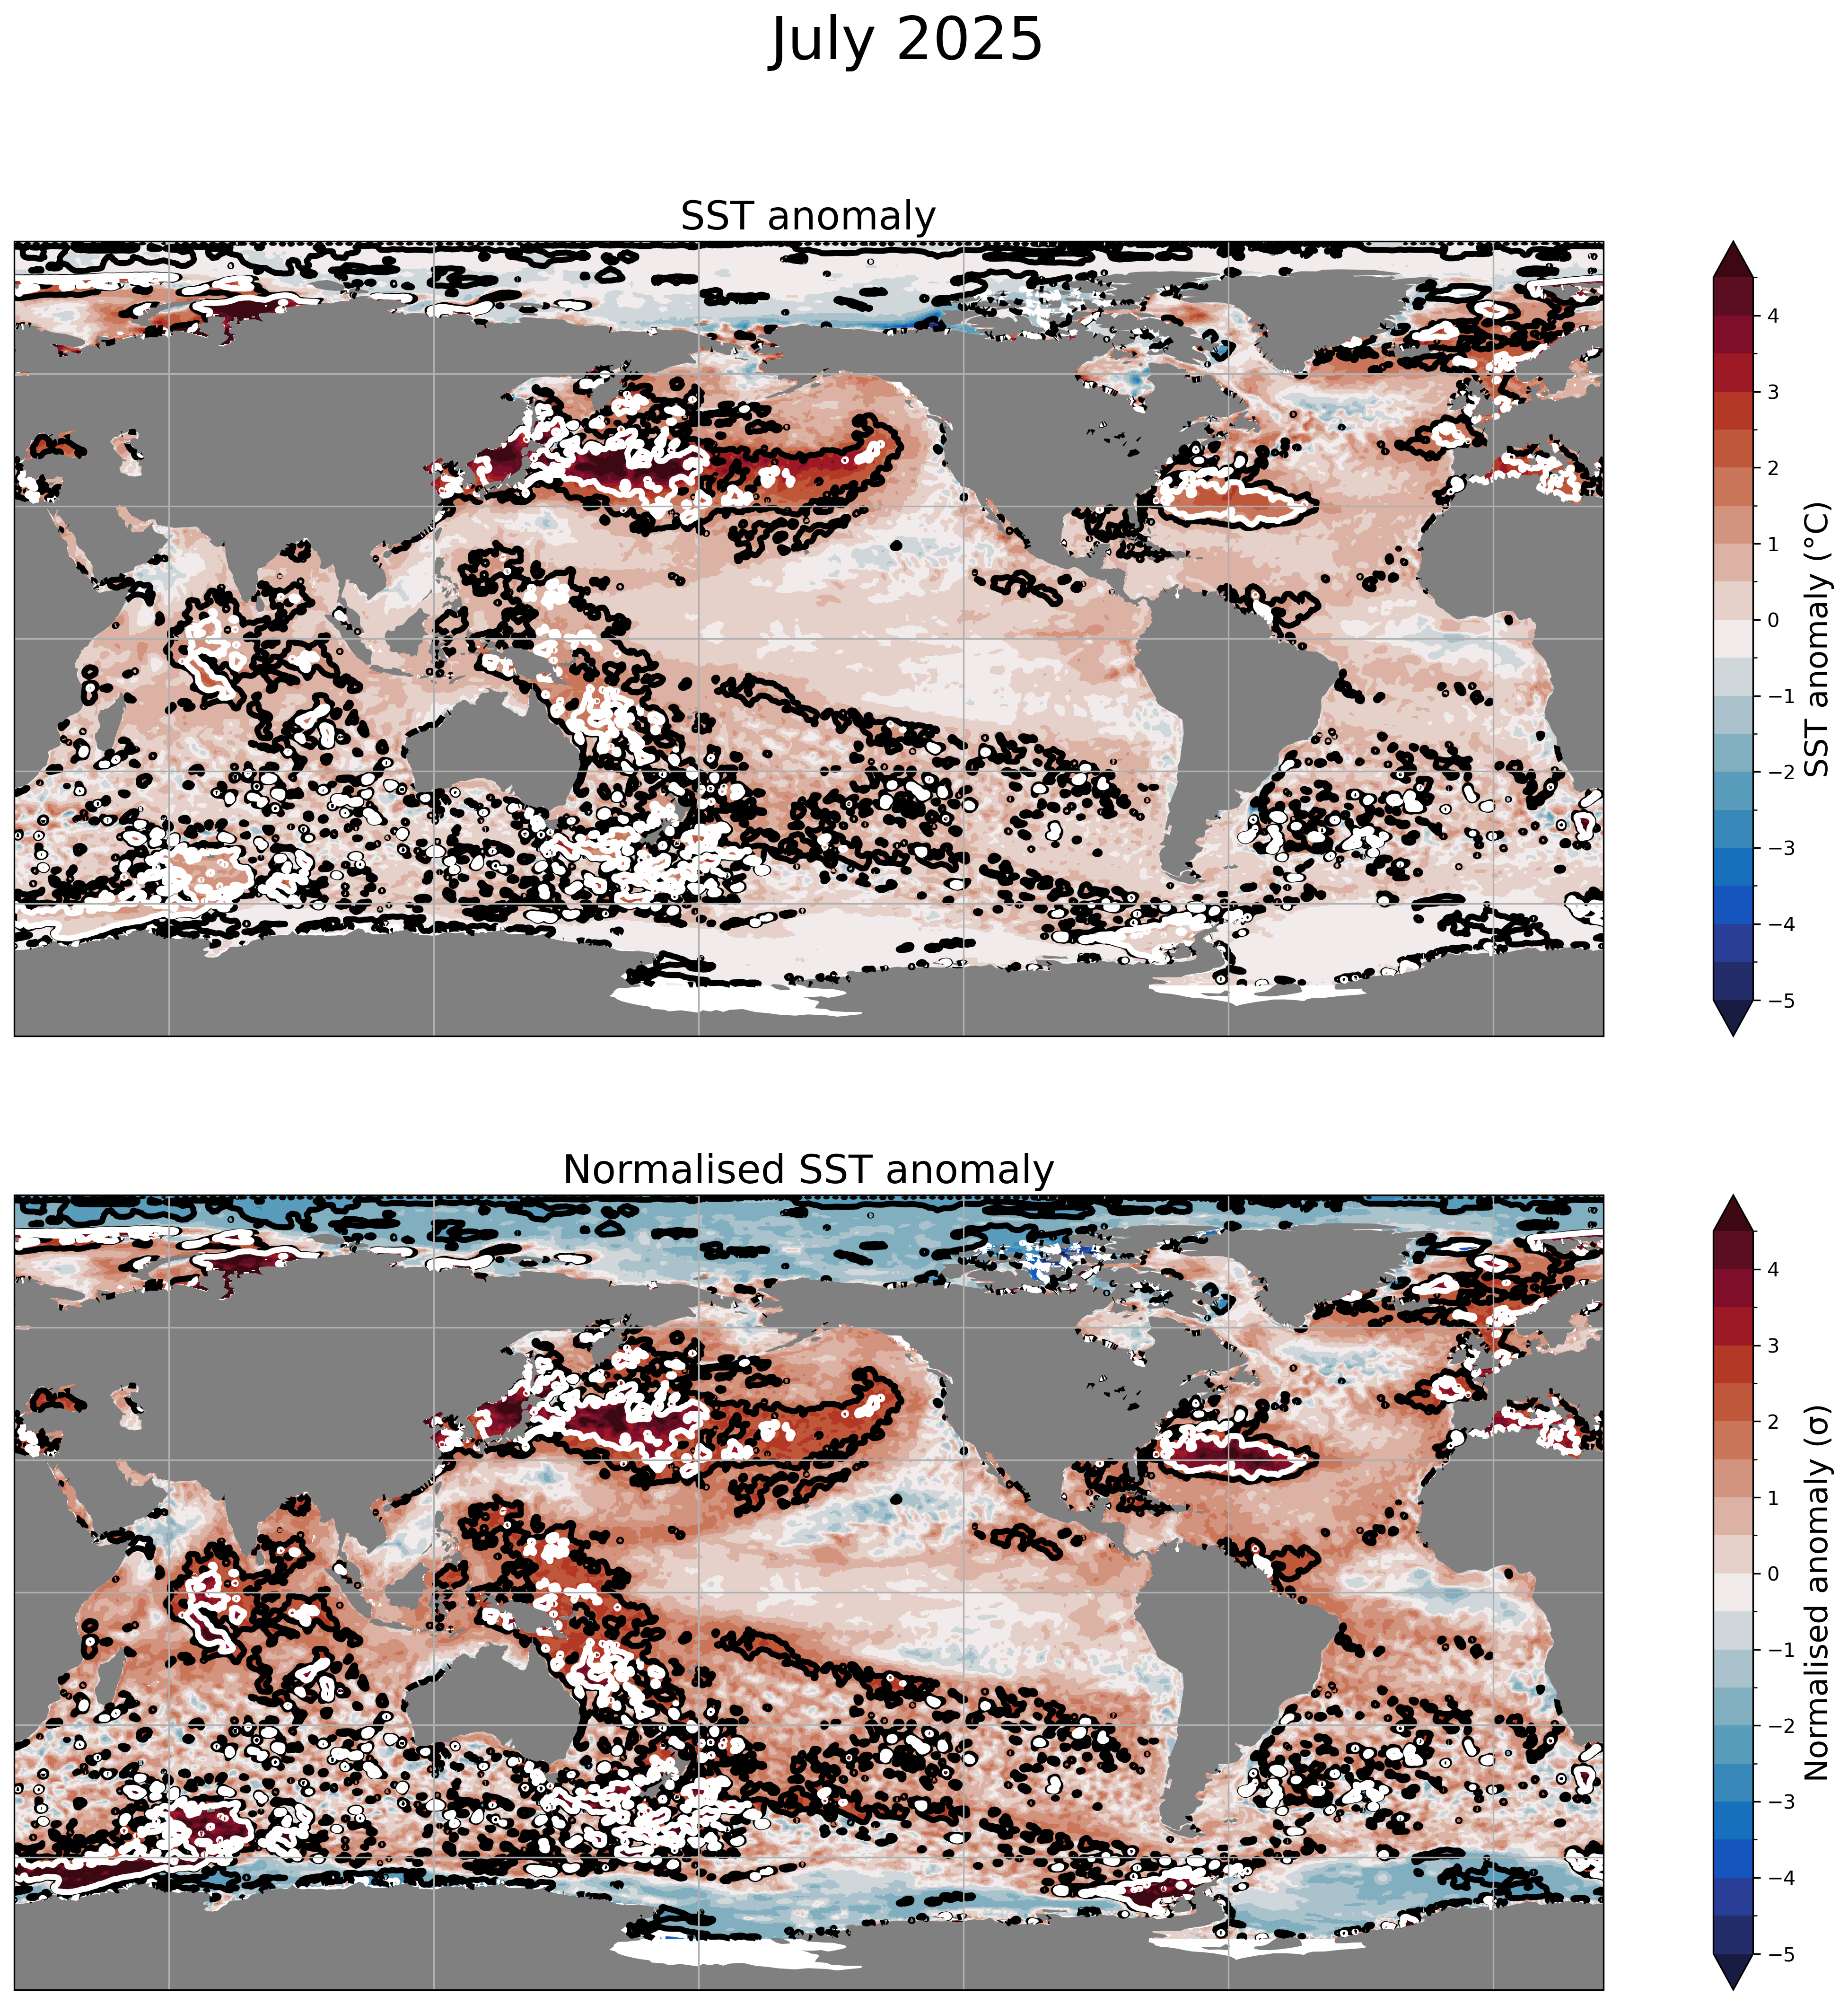

In [11]:



fig = plt.figure(figsize=(20, 16), dpi=300)

def plot_frame(pdata, normdata, fig, panel, tString, cbarString=''):

    #shift central clongitude to that Pacific Ocean is the center 
    mproj  = fig.add_subplot(2, 1, panel, projection=ccrs.crs.PlateCarree(central_longitude = -155.))
    
    mplot = pdata.plot.pcolormesh(ax=mproj, transform=ccrs.crs.PlateCarree(), cmap=colmap, levels = clev, add_colorbar=True)
    normdata.plot.contour(ax=mproj, transform=ccrs.crs.PlateCarree(),  
                           colors=['white','black','black','white'],
                           levels=[-3.,-2.,2.,3.], linewidths=3.)
    mproj.add_feature(ccrs.feature.LAND, facecolor=[0.5,0.5,0.5], zorder=1) #color land using RGB coords
    mproj.gridlines(zorder=2) 
    mproj.set_title(tString,fontsize = 20)
    mplot.colorbar.set_label(cbarString, fontsize=16)

def animate(t):
    fig.clf()  # clear figure between frames
    
    # select data for this month
    month_anom      = anom.isel(time=t).squeeze()
    month_anom_norm = anom_norm.isel(time=t).squeeze()
    month_str = str(anom.time[t].dt.strftime('%B %Y').values) # e.g. 'January'
    
    plot_frame(month_anom,   month_anom_norm,   fig, 1, f'SST anomaly',            cbarString='SST anomaly (°C)')
    plot_frame(month_anom_norm, month_anom_norm, fig, 2, f'Normalised SST anomaly', cbarString='Normalised anomaly (σ)')
    plt.suptitle(f'{month_str}', fontsize=30)

# build animation across all months
ani = animation.FuncAnimation(fig, animate, frames=len(anom.time), interval=800)


# Option A: save as gif
ani.save(diro+filo, writer='pillow', dpi=150)
